# Project 2: Animal classification - Alisa Podolska, Yulian Kisil

In [1]:
import torch
torch.cuda.is_available()

False

In [2]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd 
import numpy as np
import os
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError
import random
from sklearn.model_selection import train_test_split
import shutil
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torchvision import datasets
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms.functional as F
import wandb

## EDA

In [3]:
data_dir = "./dataset/raw-img"

### Translation (needed only first time)

In [4]:
mapping = {
    "cane": "dog",
    "cavallo": "horse",
    "elefante": "elephant",
    "farfalla": "butterfly",
    "gallina": "chicken",
    "gatto": "cat",
    "mucca": "cow",
    "pecora": "sheep",
    "ragno": "spider",
    "scoiattolo": "squirrel"
}
for old_name, new_name in mapping.items():
    old_path = os.path.join(data_dir, old_name)
    new_path = os.path.join(data_dir, new_name)

    if os.path.exists(old_path):
        os.rename(old_path, new_path)
    else:
        print(f"Folder'{old_name}' not found.")


Folder'cane' not found.
Folder'cavallo' not found.
Folder'elefante' not found.
Folder'farfalla' not found.
Folder'gallina' not found.
Folder'gatto' not found.
Folder'mucca' not found.
Folder'pecora' not found.
Folder'ragno' not found.
Folder'scoiattolo' not found.


In [5]:
classes = os.listdir(data_dir)
print("Classes:", classes)

for cls in classes:
    cnt = len(os.listdir(os.path.join(data_dir, cls)))
    print(f"{cls}: {cnt} images")

Classes: ['cat', 'butterfly', 'dog', 'sheep', 'spider', 'chicken', 'horse', 'squirrel', 'cow', 'elephant']
cat: 1668 images
butterfly: 2112 images
dog: 4863 images
sheep: 1820 images
spider: 4821 images
chicken: 3098 images
horse: 2623 images
squirrel: 1862 images
cow: 1866 images
elephant: 1446 images


### Visual sanity-chack

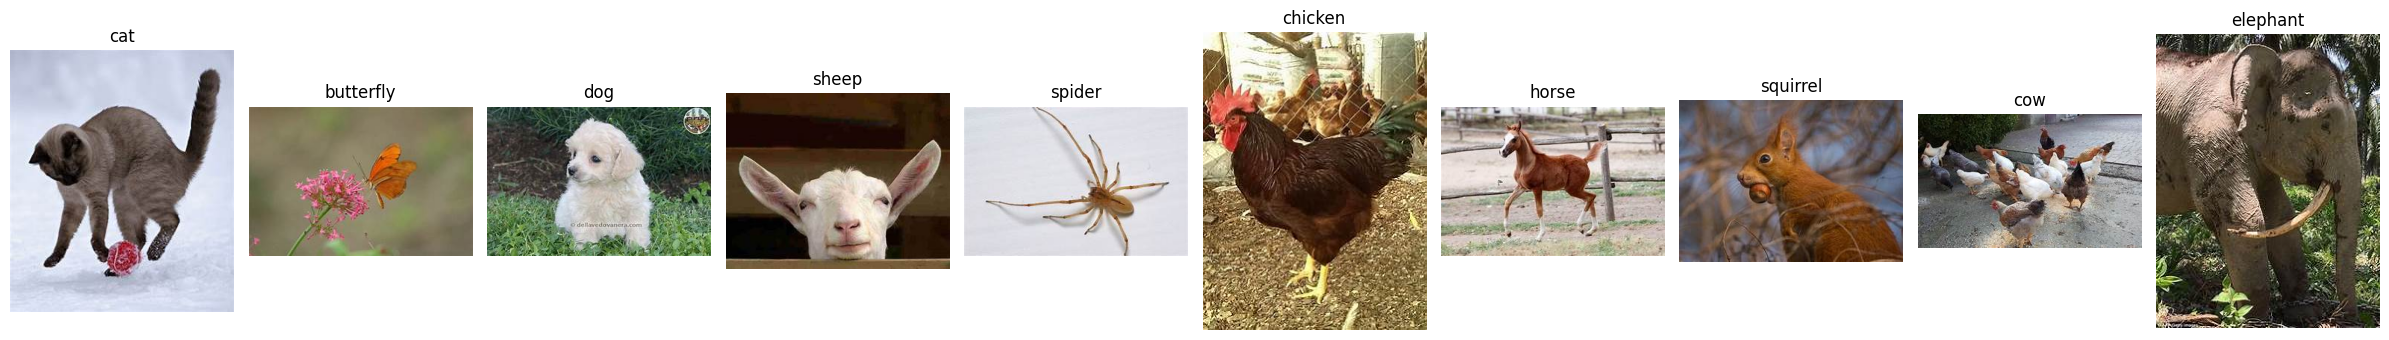

In [6]:
plt.figure(figsize=(24, 8))

for i, cls in enumerate(classes):
    cls_dir = os.path.join(data_dir, cls)
    img_name = random.choice(os.listdir(cls_dir))
    img_path = os.path.join(cls_dir, img_name)
    
    img = Image.open(img_path)

    plt.subplot(1, len(classes), i + 1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

### Distribution

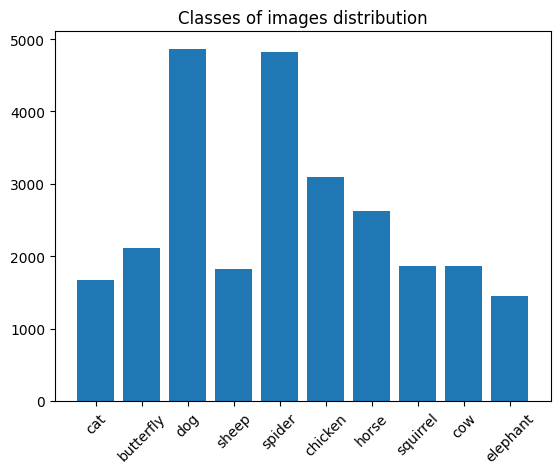

In [7]:
counts = {cls: len(os.listdir(os.path.join(data_dir, cls))) for cls in classes}
plt.bar(counts.keys(), counts.values())
plt.xticks(rotation=45)
plt.title("Classes of images distribution")
plt.show()

### Checking format, size and aspect-reisho

In [8]:
shapes=[]
channels=[]

for cls in classes:
    for img_name in os.listdir(os.path.join(data_dir,cls))[:200]:
        img=Image.open(os.path.join(data_dir,cls,img_name))
        shapes.append(img.size);channels.append(img.mode)
        
shapes=np.array(shapes)
print("Avarage size:",shapes.mean(axis=0))
print("Min:",shapes.min(axis=0))
print("Max:",shapes.max(axis=0))
print("Channels:",set(channels))

Avarage size: [331.0805 258.0235]
Min: [112  92]
Max: [6000 4000]
Channels: {'RGB', 'RGBA'}


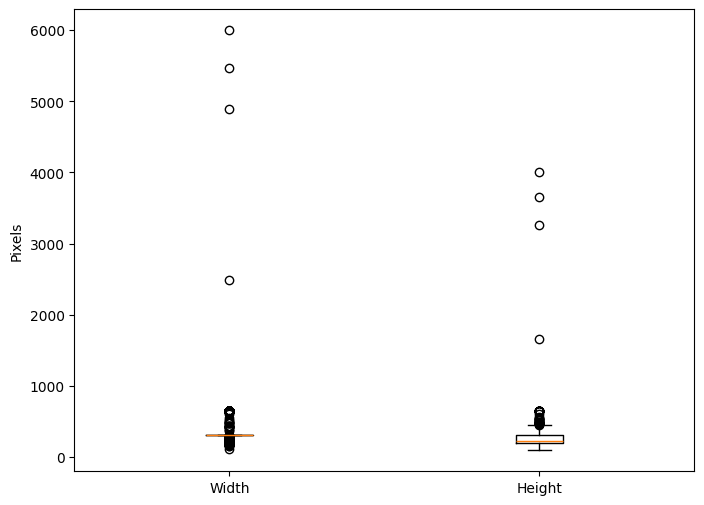

In [9]:

shapes = []
channels = []

for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    for img_name in os.listdir(cls_path)[:200]:
        img_path = os.path.join(cls_path, img_name)
        img = Image.open(img_path)
        shapes.append(img.size)
        channels.append(img.mode)

shapes = np.array(shapes)
widths = shapes[:, 0]
heights = shapes[:, 1]

plt.figure(figsize=(8, 6))
plt.boxplot([widths, heights], labels=["Width", "Height"], showfliers=True)
plt.ylabel("Pixels")
plt.show()

### Checking for broken images

In [10]:
bad = []
for cls in classes:
    for file in os.listdir(os.path.join(data_dir, cls)):
        path = os.path.join(data_dir, cls, file)
        try:
            Image.open(path).verify()
        except:
            bad.append(path)

bad

[]

## Data preprocessing

### Data split 
Train - 70  
Validation - 20  
Test - 10

In [11]:
train_dir = "dataset/train"
val_dir = "dataset/val"
test_dir = "dataset/test"

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

for cls in classes:
    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(val_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(test_dir, cls), exist_ok=True)

    images = os.listdir(os.path.join(data_dir, cls))
    train, test = train_test_split(images, test_size=0.1, random_state=42)
    train, val = train_test_split(train, test_size=0.2, random_state=42)

    for name in train:
        shutil.copy(os.path.join(data_dir, cls, name), os.path.join(train_dir, cls, name))

    for name in val:
        shutil.copy(os.path.join(data_dir, cls, name), os.path.join(val_dir, cls, name))

    for name in test:
        shutil.copy(os.path.join(data_dir, cls, name), os.path.join(test_dir, cls, name))

### Resize + mormalization

In [12]:
img_size = 224

train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

### Data Augmentation (only for train)

In [13]:
train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomResizedCrop(img_size, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

The image is first resized, then randomly flipped horizontally to simulate mirrored views. A small random rotation is applied to introduce orientation variation. ColorJitter is used to slightly change brightness, contrast, and saturation, making the model less sensitive to lighting conditions. RandomResizedCrop selects and zooms into a random part of the image to help the model learn from different object scales and positions. Finally, the image is converted to a tensor and normalized using the standard ImageNet mean and standard deviation.

### Vizualisation

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


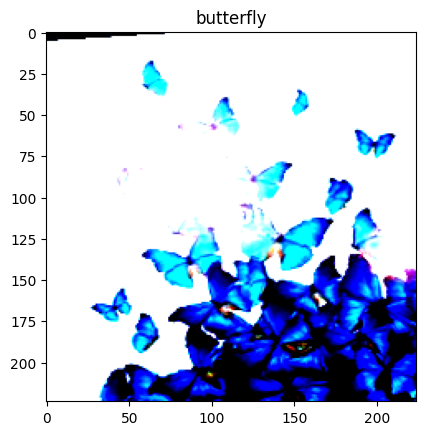

In [14]:
dataset = datasets.ImageFolder(train_dir, transform=train_transform)
img, label = dataset[0]

plt.imshow(img.permute(1,2,0))
plt.title(dataset.classes[label])
plt.show()


### DataLoader

In [15]:
train_ds = datasets.ImageFolder(train_dir, transform=train_transform)
val_ds = datasets.ImageFolder(val_dir, transform=val_transform)
test_ds = datasets.ImageFolder(test_dir, transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)
test_loader = DataLoader(test_ds, batch_size=32)

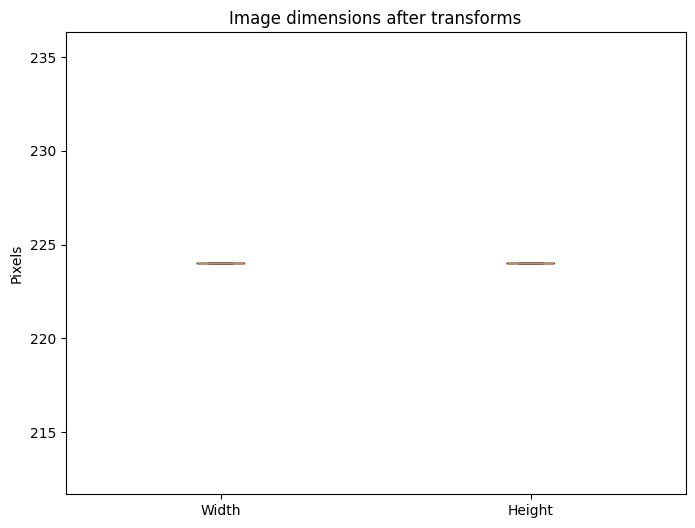

In [16]:
resized_widths = []
resized_heights = []

for img, _ in train_ds:      
    _, h, w = img.shape      
    resized_widths.append(w)
    resized_heights.append(h)
plt.figure(figsize=(8, 6))
plt.boxplot([resized_widths, resized_heights], labels=["Width", "Height"], showfliers=True)
plt.title("Image dimensions after transforms")
plt.ylabel("Pixels")
plt.show()

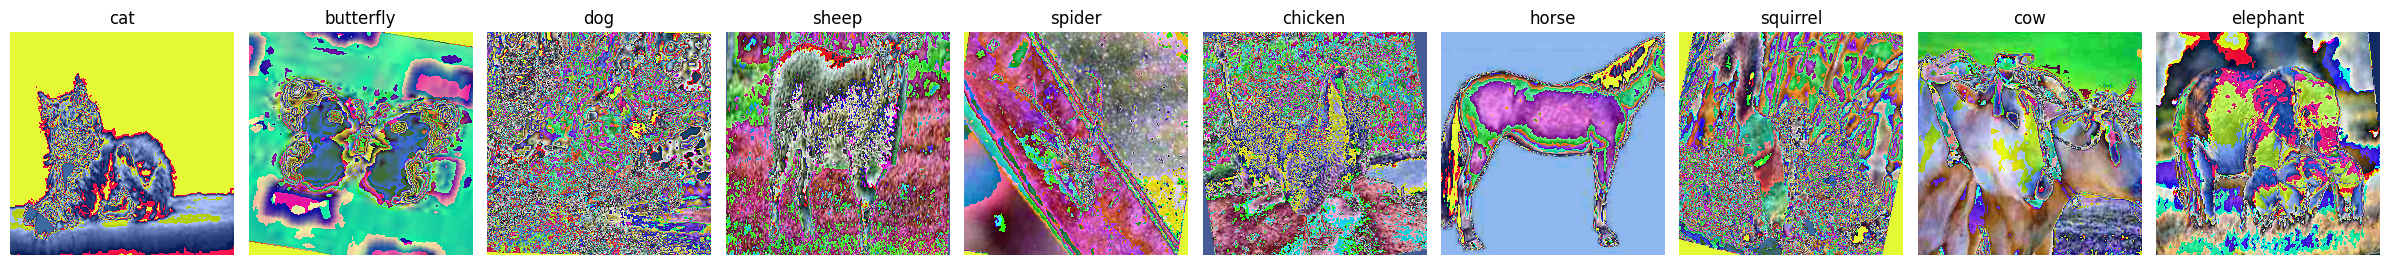

In [17]:
plt.figure(figsize=(24, 8))

for i, cls in enumerate(classes):
    class_idx = train_ds.class_to_idx[cls]
    indices = [j for j, (_, label) in enumerate(train_ds.samples) if label == class_idx]
    idx = random.choice(indices)

    img, _ = train_ds[idx]
    img = F.to_pil_image(img)

    plt.subplot(1, len(classes), i + 1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Week 2

### Model parametrs and architectures

### Our first small CNN

### Imports and Config Loading

In [42]:
import json
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader  # Assuming train_loader, val_loader, test_loader defined earlier
import wandb
import time
from torch.optim.lr_scheduler import StepLR


# Function to load config from JSON
def load_config(config_path='config.json'):
    with open(config_path, 'r') as f:
        config = json.load(f)
    print(f"Loaded config: {config['model']['name']} from {config_path}")
    return config


config = load_config('config.json')  # v1: basic

img_size = config['model']['input_size']
batch_size = config['training']['batch_size']
num_classes = config['model']['num_classes']
device = config['training']['device']
epochs = config['training']['epochs']

Loaded config: CustomCNN_v1 from config.json


In [43]:
class ConfigurableAnimalModel(nn.Module):
    def __init__(self, config):
        super(ConfigurableAnimalModel, self).__init__()
        self.config = config
        model_cfg = config['model']
        train_cfg = config['training']

        self.features = nn.Sequential()
        prev_out_ch = model_cfg['blocks'][0]['in_channels']
        use_bn = train_cfg.get('use_bn', False) 

        for i, block_cfg in enumerate(model_cfg['blocks']):
            block = nn.Sequential(
                nn.Conv2d(block_cfg['in_channels'], block_cfg['out_channels'],
                          kernel_size=block_cfg['kernel_size'], padding=block_cfg['padding'])
            )
            if use_bn: 
                block.add_module('bn', nn.BatchNorm2d(block_cfg['out_channels']))
            block.add_module('relu', nn.ReLU())
            block.add_module('pool', nn.MaxPool2d(2))
            self.features.add_module(f'conv_block_{i}', block)
            prev_out_ch = block_cfg['out_channels']

        num_pools = len(model_cfg['blocks'])
        feat_h = model_cfg['input_size'] // (2 ** num_pools)
        feat_w = model_cfg['input_size'] // (2 ** num_pools)
        linear_input = prev_out_ch * feat_h * feat_w

        classifier_cfg = model_cfg['classifier']
        self.classifier = nn.Sequential()
        self.classifier.add_module('flatten', nn.Flatten())
        current_size = linear_input
        fc_layers = classifier_cfg.get('fc_layers',
                                       [{'in': None, 'out': classifier_cfg['hidden_size']}])  # Default: 1 layer
        for j, layer_cfg in enumerate(fc_layers):
            in_size = linear_input if layer_cfg['in'] is None else layer_cfg['in'] 
            self.classifier.add_module(f'fc_{j}', nn.Linear(in_size, layer_cfg['out']))
            self.classifier.add_module(f'relu_{j}', nn.ReLU())
            current_size = layer_cfg['out']

        self.classifier.add_module('dropout', nn.Dropout(classifier_cfg['dropout_rate']))

        self.classifier.add_module('out', nn.Linear(current_size, model_cfg['num_classes']))

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

    @classmethod
    def from_config(cls, config_path):  # Static method for easy creation
        config = load_config(config_path)
        return cls(config)


In [44]:
model = ConfigurableAnimalModel.from_config('config.json').to(device)

Loaded config: CustomCNN_v1 from config.json


### Loss and Optimizer Setup

In [45]:
train_cfg = config['training']

if train_cfg['criterion'] == 'CrossEntropyLoss':
    criterion = nn.CrossEntropyLoss()
else:
    raise ValueError(f"Unsupported criterion: {train_cfg['criterion']}")

optimizer_class = getattr(optim, train_cfg['optimizer'])
optimizer_kwargs = {'lr': train_cfg['lr']}
if train_cfg['optimizer'] == 'SGD':
    optimizer_kwargs['momentum'] = train_cfg.get('momentum', 0.9)  # For v3
optimizer = optimizer_class(model.parameters(), **optimizer_kwargs)

### Training

In [46]:
def train_epoch(model, loader, criterion, optimizer):
    model_t = 0
    loader_t = 0
    model.train()
    total_loss, total_correct = 0, 0
    prev_time = time.perf_counter()
    for images, labels in loader:
        loader_time = time.perf_counter() - prev_time
        loader_t += loader_time
        images, labels = images.to(device), labels.to(device)
        model_start = time.perf_counter()
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        total_correct += (outputs.argmax(1) == labels).sum().item()
        prev_time = time.perf_counter()
        model_t += prev_time - model_start
    print(f"Model time: {model_t:.2f}s, Loader time: {loader_t:.2f}s")

    return total_loss / len(loader.dataset), total_correct / len(loader.dataset)

### Validation

In [47]:
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, total_correct = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            total_correct += (outputs.argmax(1) == labels).sum().item()

    return total_loss / len(loader.dataset), total_correct / len(loader.dataset)

### First experiment + Wandb

In [49]:
exp_cfg = config['experiment']
wandb.login()

wandb.init(
    project=exp_cfg['wandb_project'],
    name=exp_cfg['wandb_name'],
    config=config  
)
for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, config)
    val_loss, val_acc = eval_epoch(model, val_loader, criterion)

    print(f"[v1 {epoch + 1}/{epochs}] Train Acc={train_acc:.4f}  Val Acc={val_acc:.4f}")
    wandb.log({
        "epoch": epoch + 1,
        "train/loss": train_loss,
        "train/accuracy": train_acc,
        "val/loss": val_loss,
        "val/accuracy": val_acc,
    })
wandb.finish()


test_loss_v1, test_acc_v1 = eval_epoch(model, test_loader, criterion)
print(f"[v1 Final] Test Acc={test_acc_v1:.4f}")

KeyboardInterrupt: 

### Custom Configurable Model — Experiment v2 

In this experiment, we train the second version of our **ConfigurableAnimalModel**, where the entire architecture and training setup are controlled through an external JSON configuration. The model is built dynamically using the `from_config()` method, which constructs convolutional layers, fully connected layers, dropout, and batch normalization exactly as described in `config_v2.json`. The training loop uses standard CrossEntropyLoss together with an optimizer defined in the config (e.g., Adam), and all hyperparameters such as learning rate, batch size, and number of epochs are sourced directly from the configuration file. Throughout the run, we log accuracy and loss metrics to **Weights & Biases** to track progress and compare with other configurations. After training, we also evaluate the model on the test set to measure its final performance.


In [50]:
config_v2 = load_config('config_v2.json')
model_v2 = ConfigurableAnimalModel.from_config('config_v2.json').to(device)  # Static method

train_cfg_v2 = config_v2['training']
if train_cfg_v2['criterion'] == 'CrossEntropyLoss':
    criterion_v2 = nn.CrossEntropyLoss()
else:
    raise ValueError(f"Unsupported: {train_cfg_v2['criterion']}")

optimizer_class_v2 = getattr(optim, train_cfg_v2['optimizer'])
optimizer_v2 = optimizer_class_v2(model_v2.parameters(), lr=train_cfg_v2['lr'])

epochs_v2 = config_v2['training']['epochs']

exp_cfg_v2 = config_v2['experiment']
wandb.init(
    project=exp_cfg_v2['wandb_project'],
    name=exp_cfg_v2['wandb_name'],  # "CustomCNN_v2_Deeper"
    config=config_v2
)

for epoch in range(epochs_v2):
    train_loss, train_acc = train_epoch(model_v2, train_loader, criterion_v2, optimizer_v2, config_v2)
    val_loss, val_acc = eval_epoch(model_v2, val_loader, criterion_v2)

    print(f"[v2 {epoch + 1}/{epochs_v2}] Train Acc={train_acc:.4f}  Val Acc={val_acc:.4f}")
    wandb.log({
        "epoch": epoch + 1,
        "train/loss": train_loss,
        "train/accuracy": train_acc,
        "val/loss": val_loss,
        "val/accuracy": val_acc,
    })

wandb.finish()

test_loss_v2, test_acc_v2 = eval_epoch(model_v2, test_loader, criterion_v2)
print(f"[v2 Final] Test Acc={test_acc_v2:.4f}")

Loaded config: CustomCNN_v2 from config_v2.json
Loaded config: CustomCNN_v2 from config_v2.json


KeyboardInterrupt: 


### Custom Configurable Model — Experiment v3

This experiment trains the third version of the **ConfigurableAnimalModel**, which includes a more advanced training setup defined in `config_v3.json`. Along with configurable architecture and optimizer settings, this version introduces **SGD with momentum** and optionally a **learning rate scheduler (StepLR)** to improve training stability and convergence. As in previous versions, all components of the model—including convolution blocks, batch normalization, dropout, and fully connected layers—are built dynamically through the configuration system. During each epoch, we log training and validation metrics to **Weights & Biases**, along with the current learning rate to monitor scheduler behavior. After finishing all epochs, we compute the final test accuracy to evaluate how the scheduler and updated training strategy influence performance.

In [51]:
config_v3 = load_config('config_v3.json')
model_v3 = ConfigurableAnimalModel.from_config('config_v3.json').to(device)

train_cfg_v3 = config_v3['training']
if train_cfg_v3['criterion'] == 'CrossEntropyLoss':
    criterion_v3 = nn.CrossEntropyLoss()
else:
    raise ValueError(f"Unsupported: {train_cfg_v3['criterion']}")

optimizer_class_v3 = getattr(optim, train_cfg_v3['optimizer'])
optimizer_v3 = optimizer_class_v3(model_v3.parameters(), lr=train_cfg_v3['lr'], momentum=0.9)

scheduler_cfg = train_cfg_v3.get('scheduler', {})
scheduler_v3 = None
if scheduler_cfg.get('type') == 'StepLR':
    scheduler_v3 = StepLR(optimizer_v3, step_size=scheduler_cfg['step_size'], gamma=scheduler_cfg['gamma'])

epochs_v3 = config_v3['training']['epochs']

exp_cfg_v3 = config_v3['experiment']
wandb.init(
    project=exp_cfg_v3['wandb_project'],
    name=exp_cfg_v3['wandb_name'],  # "CustomCNN_v3_BN_SGD_Scheduler"
    config=config_v3
)

for epoch in range(epochs_v3):
    train_loss, train_acc = train_epoch(model_v3, train_loader, criterion_v3, optimizer_v3, config_v3)
    val_loss, val_acc = eval_epoch(model_v3, val_loader, criterion_v3)

    print(
        f"[v3 {epoch + 1}/{epochs_v3}] Train Acc={train_acc:.4f}  Val Acc={val_acc:.4f}  LR={optimizer_v3.param_groups[0]['lr']:.6f}")
    wandb.log({
        "epoch": epoch + 1,
        "train/loss": train_loss,
        "train/accuracy": train_acc,
        "val/loss": val_loss,
        "val/accuracy": val_acc,
        "lr": optimizer_v3.param_groups[0]['lr']
    })

    if scheduler_v3:
        scheduler_v3.step()

wandb.finish()

test_loss_v3, test_acc_v3 = eval_epoch(model_v3, test_loader, criterion_v3)
print(f"[v3 Final] Test Acc={test_acc_v3:.4f}")

Loaded config: CustomCNN_v3 from config_v3.json
Loaded config: CustomCNN_v3 from config_v3.json


KeyboardInterrupt: 

## Week 3

### LeNet

In this section, we train **LeNet**, one of the earliest convolutional neural networks, originally designed for handwritten digit recognition. Although simple by today’s standards, it is a useful baseline model to compare against deeper and more modern architectures. Our LeNet implementation uses two convolution–pooling blocks followed by a small fully connected classifier, adapted to handle 224×224 RGB images and output 10 classes for the Animals10 dataset.

The model is trained for 15 epochs using the Adam optimizer and CrossEntropyLoss, with all metrics logged to **Weights & Biases**. During each epoch, we monitor both training and validation accuracy to evaluate how well this classic architecture performs on a more complex, real-world dataset.


In [20]:
import os
os.environ["WANDB_DISABLE_CORE"] = "true"
os.environ["WANDB_REQUIRE_SERVICE"] = "true"


In [21]:
import wandb
wandb.init(project="animals", entity="xpodolskaa-stuba")


In [22]:
class LeNet(nn.Module):
    def __init__(self, num_classes):
        super(LeNet, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 6, kernel_size=5),   # 3 → 6
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(6, 16, kernel_size=5), # 6 → 16
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # 224 х 224
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 53 * 53, 120),
            nn.ReLU(),
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Linear(84, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [23]:
model = LeNet(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)


In [30]:
import wandb
wandb.login()

wandb.init(
    project="animals",
    name="LeNet",
    config={
        "epochs": 15,
        "lr": 1e-4,
        "batch_size": train_loader.batch_size,
        "optimizer": "Adam",
        "model": "LeNet"
    }
)


wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


In [ ]:
wandb.login()

wandb.init(
    project="animals",
    name="LeNet",
    config={
        "epochs": 15,
        "lr": 1e-4,
        "batch_size": train_loader.batch_size,
        "optimizer": "Adam",
        "model": "LeNet"
    }
)
epochs = 15

for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = eval_epoch(model, val_loader, criterion)

    print(f"[{epoch+1}/{epochs}] Train Acc={train_acc:.4f}  Val Acc={val_acc:.4f}")

    
    wandb.log({
        "epoch": epoch + 1,
        "train/loss": train_loss,
        "train/accuracy": train_acc,
        "val/loss": val_loss,
        "val/accuracy": val_acc,
    })

In [31]:
epochs = 15

for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = eval_epoch(model, val_loader, criterion)

    print(f"[{epoch+1}/{epochs}] Train Acc={train_acc:.4f}  Val Acc={val_acc:.4f}")

    
    wandb.log({
        "epoch": epoch + 1,
        "train/loss": train_loss,
        "train/accuracy": train_acc,
        "val/loss": val_loss,
        "val/accuracy": val_acc,
    })


7.421533321263269
71.8319747033529
[1/15] Train Acc=0.4361  Val Acc=0.4662
7.4198644566349685
68.82559059909545
[2/15] Train Acc=0.4587  Val Acc=0.4847
7.421509635169059
67.73284270893782
[3/15] Train Acc=0.4759  Val Acc=0.4890
7.421467535197735
68.79699815995991
[4/15] Train Acc=0.4966  Val Acc=0.4851
7.432263103546575
70.76057340670377
[5/15] Train Acc=0.5037  Val Acc=0.5247
7.429230439243838
70.53141029225662
[6/15] Train Acc=0.5177  Val Acc=0.5348
7.420936400303617
69.46358028310351
[7/15] Train Acc=0.5326  Val Acc=0.5512
7.421177799347788
69.55139511218295
[8/15] Train Acc=0.5400  Val Acc=0.5616
7.426971870707348
70.45019987924024
[9/15] Train Acc=0.5499  Val Acc=0.5583
7.426169752841815
69.73099021450616
[10/15] Train Acc=0.5598  Val Acc=0.5522
7.416563962586224
67.32665295526385
[11/15] Train Acc=0.5774  Val Acc=0.5817
7.426847729599103
72.79298161272891
[12/15] Train Acc=0.5825  Val Acc=0.5788
7.42227708385326
70.94592385715805
[13/15] Train Acc=0.5864  Val Acc=0.5772
7.4139908

### AlexNet

In this part of the project, we experiment with **AlexNet**, the breakthrough CNN architecture that won the ImageNet competition in 2012 and helped launch the deep learning wave in computer vision. We load the pretrained ImageNet version and replace its final fully connected layer so the model outputs 10 classes for the Animals10 dataset. The network is trained for 15 epochs using the Adam optimizer and CrossEntropyLoss, with all training and validation metrics logged to **Weights & Biases**.

Throughout each epoch, we monitor accuracy and loss to track how effectively AlexNet learns the dataset. Even though AlexNet is older and simpler compared to modern networks, it still performs surprisingly well on medium-sized image classification tasks.


In [23]:
from torchvision.models import alexnet

In [24]:
def build_alexnet(num_classes):
    model = alexnet(weights="IMAGENET1K_V1")   # предобученные веса
    model.classifier[6] = nn.Linear(4096, num_classes)  # заменяем последний слой
    return model.to(device)


In [25]:
model = build_alexnet(num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)


In [ ]:
wandb.init(
    project="animals",
    name="AlexNet",
    config={
        "epochs": 15,
        "lr": 1e-4,
        "batch_size": train_loader.batch_size,
        "optimizer": "Adam",
        "model": model
    }
)
for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = eval_epoch(model, val_loader, criterion)

    print(f"[{epoch+1}/{epochs}] Train Acc={train_acc:.4f}  Val Acc={val_acc:.4f}")
    wandb.log({
        "epoch": epoch + 1,
        "train/loss": train_loss,
        "train/accuracy": train_acc,
        "val/loss": val_loss,
        "val/accuracy": val_acc,
    })

/home/podolska/myenv/lib/python3.10/site-packages/wandb/sdk/launch/builder/build.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
wandb: Currently logged in as: xpodolskaa (xpodolskaa-stuba). Use `wandb login --relogin` to force relogin


16.848692106315866
66.68570812093094
[1/15] Train Acc=0.8305  Val Acc=0.8990
16.732524557737634
67.64199622883461
[2/15] Train Acc=0.8916  Val Acc=0.9227
16.73036651685834
67.47659143712372
[3/15] Train Acc=0.9098  Val Acc=0.9376
16.732669255696237
67.57861788664013
[4/15] Train Acc=0.9202  Val Acc=0.9380
16.728441367391497
67.61673675524071
[5/15] Train Acc=0.9313  Val Acc=0.9542
16.736273617949337
67.24862291757017
[6/15] Train Acc=0.9349  Val Acc=0.9578
16.73708530375734
67.36303801648319
[7/15] Train Acc=0.9391  Val Acc=0.9500
16.73006309219636
67.06758893141523
[8/15] Train Acc=0.9488  Val Acc=0.9571
16.729066040134057
67.6279495714698
[9/15] Train Acc=0.9501  Val Acc=0.9510


### VGG-16

In this section, we work with **VGG-16**, one of the most iconic CNN architectures known for its simple but very deep design built entirely from stacked 3×3 convolution layers. We load the pretrained ImageNet version of VGG-16 and replace its final classifier layer so it outputs 10 classes instead of 1000, preparing it for the Animals10 dataset. The model is trained for 15 epochs using the Adam optimizer together with CrossEntropyLoss, and all metrics are logged to **Weights & Biases** for convenient tracking and visualization. 

Throughout training, we monitor both training and validation accuracy to observe how the model learns and how well it generalizes. Because of its depth and consistent structure, VGG-16 often delivers stable performance and acts as a strong baseline in image classification tasks.


In [ ]:
from torchvision.models import vgg16

In [ ]:
def build_vgg16(num_classes):
    model = vgg16(weights="IMAGENET1K_V1") 
    model.classifier[6] = nn.Linear(4096, num_classes)

    return model.to(device)

In [ ]:
model = build_vgg16(num_classes)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
wandb.init(
    project="animals",
    name="VGG16",
    config={
        "epochs": 15,
        "lr": 1e-4,
        "batch_size": train_loader.batch_size,
        "optimizer": "Adam",
        "model": model
    }
)
for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = eval_epoch(model, val_loader, criterion)

    print(f"[{epoch+1}/{epochs}] Train Acc={train_acc:.4f}  Val Acc={val_acc:.4f}")
    wandb.log({
        "epoch": epoch + 1,
        "train/loss": train_loss,
        "train/accuracy": train_acc,
        "val/loss": val_loss,
        "val/accuracy": val_acc,
    })

### Inception-v1 

In this part of the project, we train **Inception-v1 (GoogLeNet)**, a model famous for its Inception modules that process the image at multiple filter sizes in parallel. This architecture also includes **auxiliary classifiers**, which act as additional branches helping the network learn more easily in early layers. We load the pretrained ImageNet version, replace the main classifier and both auxiliary heads to output 10 classes, and prepare the model for fine-tuning on Animals10.

Because Inception produces three outputs (main + two auxiliary), the training step uses a special loss function: the main loss plus two auxiliary losses weighted by 0.3 each. This helps stabilize training and improves gradient flow. During each epoch, we compute training and validation accuracy and log all metrics to **Weights & Biases**, following the same schedule as the other models. The overall setup allows us to evaluate how well the multi-branch Inception architecture adapts to our classification task.


In [ ]:
from torchvision.models import googlenet

In [ ]:
def build_inception_v1(num_classes):
    model = googlenet(weights="IMAGENET1K_V1", aux_logits=True)
    model.fc = nn.Linear(1024, num_classes)

    if model.aux_logits:
        model.aux1.fc2 = nn.Linear(1024, num_classes)
        model.aux2.fc2 = nn.Linear(1024, num_classes)

    return model.to(device)

In [ ]:
model = build_inception_v1(num_classes)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
def train_epoch_inception(model, loader, criterion, optimizer):
    model.train()
    total_loss, total_correct = 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        if isinstance(outputs, tuple):
            main_output, aux1_output, aux2_output = outputs

            loss1 = criterion(main_output, labels)
            loss2 = criterion(aux1_output, labels)
            loss3 = criterion(aux2_output, labels)

        
            loss = loss1 + 0.3 * loss2 + 0.3 * loss3
        else:
            loss = criterion(outputs, labels)
            main_output = outputs

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        total_correct += (main_output.argmax(1) == labels).sum().item()

    return total_loss / len(loader.dataset), total_correct / len(loader.dataset)

In [ ]:
def eval_epoch_inception(model, loader, criterion):
    model.eval()
    total_loss, total_correct = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            if isinstance(outputs, tuple): 
                outputs = outputs[0]

            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            total_correct += (outputs.argmax(1) == labels).sum().item()

    return total_loss / len(loader.dataset), total_correct / len(loader.dataset)

In [ ]:
wandb.init(
    project="animals",
    name="Inception",
    config={
        "epochs": 15,
        "lr": 1e-4,
        "batch_size": train_loader.batch_size,
        "optimizer": "Adam",
        "model": model
    }
)
for epoch in range(epochs):
    train_loss, train_acc = train_epoch_inception(model, train_loader, criterion, optimizer)
    val_loss, val_acc     = eval_epoch_inception(model, val_loader, criterion)
    print(f"[{epoch+1}/{epochs}] Train Acc={train_acc:.4f}  Val Acc={val_acc:.4f}")
    wandb.log({
        "epoch": epoch + 1,
        "train/loss": train_loss,
        "train/accuracy": train_acc,
        "val/loss": val_loss,
        "val/accuracy": val_acc,
    })

### ResNet-50

### ResNet-50 Experiment Summary

Here we use **ResNet-50**, a deep convolutional neural network built on the idea of residual connections, which allow the model to train much deeper architectures without suffering from vanishing gradients. We load the pretrained ImageNet version of ResNet-50 and replace its final fully connected layer to match the 10 classes of the Animals10 dataset. The model is trained for 15 epochs using the Adam optimizer and CrossEntropyLoss, with all training and validation metrics logged to **Weights & Biases**. Each epoch provides updated accuracy and loss values, helping us observe how consistently and effectively the model learns. ResNet-50 is known for strong performance across many vision tasks thanks to its stable residual block design.


In [ ]:
from torchvision.models import resnet50

In [ ]:
def build_resnet50(num_classes):
    model = resnet50(weights="IMAGENET1K_V1")
    model.fc = nn.Linear(2048, num_classes)
    
    return model.to(device)


In [ ]:
model = build_resnet50(num_classes)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
wandb.init(
    project="animals",
    name="ResNet",
    config={
        "epochs": 15,
        "lr": 1e-4,
        "batch_size": train_loader.batch_size,
        "optimizer": "Adam",
        "model": model
    }
)
for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = eval_epoch(model, val_loader, criterion)

    print(f"[{epoch+1}/{epochs}] Train Acc={train_acc:.4f}  Val Acc={val_acc:.4f}")
    wandb.log({
        "epoch": epoch + 1,
        "train/loss": train_loss,
        "train/accuracy": train_acc,
        "val/loss": val_loss,
        "val/accuracy": val_acc,
    })

### DenseNet

### DenseNet-121 Experiment Summary

In this section, we work with **DenseNet-121**, a model known for its dense connectivity, where each layer feeds into all subsequent layers, improving feature flow and efficiency. We use the pretrained ImageNet version and replace its original classifier so it outputs 10 classes for the Animals10 dataset. The model is trained for 15 epochs using the Adam optimizer and CrossEntropyLoss, and all metrics are logged to **Weights & Biases** for transparent tracking. During each epoch, we evaluate both training and validation accuracy to observe learning progress and stability. DenseNet-121 is especially strong at feature reuse, making it effective for detailed image classification tasks like this one.


In [ ]:
from torchvision.models import densenet121


In [ ]:
def build_densenet121(num_classes):
    model = densenet121(weights="IMAGENET1K_V1")  
    model.classifier = nn.Linear(1024, num_classes)

    return model.to(device)


In [ ]:
model = build_densenet121(num_classes)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)


In [ ]:
wandb.init(
    project="animals",
    name="DenseNet",
    config={
        "epochs": 15,
        "lr": 1e-4,
        "batch_size": train_loader.batch_size,
        "optimizer": "Adam",
        "model": model
    }
)
for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = eval_epoch(model, val_loader, criterion)

    print(f"[{epoch+1}/{epochs}] Train Acc={train_acc:.4f}  Val Acc={val_acc:.4f}")
    wandb.log({
        "epoch": epoch + 1,
        "train/loss": train_loss,
        "train/accuracy": train_acc,
        "val/loss": val_loss,
        "val/accuracy": val_acc,
    })

### MobileNet

### MobileNet-v2 Experiment Summary

In this section, we test **MobileNet-v2**, a lightweight CNN commonly used on mobile devices due to its speed and efficiency. We load the model with **pretrained ImageNet weights** and replace the final layer so it outputs 10 classes for the Animals10 dataset. The model is trained for 15 epochs using Adam and CrossEntropyLoss, while all metrics are logged to **Weights & Biases** for tracking. During each epoch, we compute training and validation accuracy to monitor learning progress.

In [ ]:
from torchvision.models import mobilenet_v2

In [ ]:
def build_mobilenet_v2(num_classes):
    model = mobilenet_v2(weights="IMAGENET1K_V1") 
    model.classifier[1] = nn.Linear(1280, num_classes)

    return model.to(device)


In [ ]:
model = build_mobilenet_v2(num_classes)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)


In [ ]:
wandb.init(
    project="animals",
    name="mobileNet",
    config={
        "epochs": 15,
        "lr": 1e-4,
        "batch_size": train_loader.batch_size,
        "optimizer": "Adam",
        "model": model
    }
)
for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = eval_epoch(model, val_loader, criterion)

    print(f"[{epoch+1}/{epochs}] Train Acc={train_acc:.4f}  Val Acc={val_acc:.4f}")
    wandb.log({
        "epoch": epoch + 1,
        "train/loss": train_loss,
        "train/accuracy": train_acc,
        "val/loss": val_loss,
        "val/accuracy": val_acc,
    })